In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [6]:
df = pd.read_csv("../data/processed/dataset_balanced.csv")
print(df.shape)
df.head()

(95804, 2)


,url,label
0,http://www.pbs.org/cringely/,0
1,"http://'services-runescape-com-forum-s.tk/97,1...",1
2,http://painterspaintings.com/P_mindelse-koordi...,1
3,http://www.scdyw.mobi/JS/?us.battle.net/login/...,1
4,http://www.tin.org/docs.html,0


In [7]:
print(df['label'].value_counts())
print(df.isnull().sum())

label
0    47902
1    47902
Name: count, dtype: int64
url      0
label    0
dtype: int64


In [8]:
X = df['url'].astype(str)
y = df['label'].astype(int)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 76643
Test size: 19161


In [10]:
max_words = 5000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, char_level=True, lower=False)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

X_train_pad shape: (76643, 200)
X_test_pad shape: (19161, 200)


In [11]:
print("Sample URL:", X_train.iloc[0])
print("Encoded:", X_train_seq[0][:50])
print("Padded shape:", X_train_pad[0].shape)

Sample URL: http://www.orlandosentinel.com/business/
Encoded: [13, 2, 2, 7, 22, 1, 1, 15, 15, 15, 5, 6, 14, 17, 4, 12, 16, 6, 10, 3, 12, 2, 9, 12, 3, 17, 5, 8, 6, 11, 1, 18, 20, 10, 9, 12, 3, 10, 10, 1]
Padded shape: (200,)


In [12]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

d:\phishing-detection\.venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [14]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
959/959 ━━━━━━━━━━━━━━━━━━━━ 145s 148ms/step - accuracy: 0.7539 - loss: 0.4616 - val_accuracy: 0.8839 - val_loss: 0.2853
Epoch 2/10
959/959 ━━━━━━━━━━━━━━━━━━━━ 115s 120ms/step - accuracy: 0.9019 - loss: 0.2407 - val_accuracy: 0.9169 - val_loss: 0.2115
Epoch 3/10
959/959 ━━━━━━━━━━━━━━━━━━━━ 116s 121ms/step - accuracy: 0.9241 - loss: 0.1928 - val_accuracy: 0.9119 - val_loss: 0.2191
Epoch 4/10
959/959 ━━━━━━━━━━━━━━━━━━━━ 138s 144ms/step - accuracy: 0.9370 - loss: 0.1617 - val_accuracy: 0.9329 - val_loss: 0.1679
Epoch 5/10
959/959 ━━━━━━━━━━━━━━━━━━━━ 134s 139ms/step - accuracy: 0.9463 - loss: 0.1408 - val_accuracy: 0.9453 - val_loss: 0.1430
Epoch 6/10
959/959 ━━━━━━━━━━━━━━━━━━━━ 144s 150ms/step - accuracy: 0.9508 - loss: 0.1275 - val_accuracy: 0.9468 - val_loss: 0.1360
Epoch 7/10
959/959 ━━━━━━━━━━━━━━━━━━━━ 112s 117ms/step - accuracy: 0.9557 - loss: 0.1157 - val_accuracy: 0.9513 - val_loss: 0.1204
Epoch 8/10
959/959 ━━━━━━━━━━━━━━━━━━━━ 102s 107ms/step - accuracy: 0.9609 -

In [15]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Test Loss: 0.10460879653692245
Test Accuracy: 0.9609102010726929


In [16]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

599/599 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step


In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9609101821408068

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      9581
           1       0.97      0.95      0.96      9580

    accuracy                           0.96     19161
   macro avg       0.96      0.96      0.96     19161
weighted avg       0.96      0.96      0.96     19161



In [18]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[9332  249]
 [ 500 9080]]


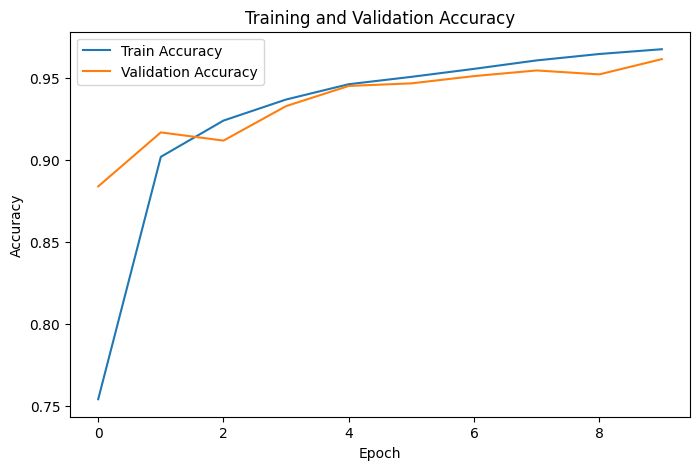

In [19]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

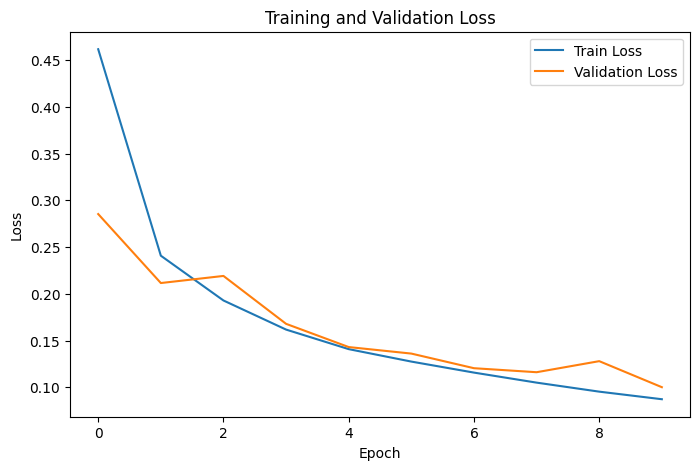

In [20]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [22]:
model.save("../models/gru_model.keras")
print("Model saved successfully.")

Model saved successfully.


In [24]:
import pickle

with open("../models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved successfully.")

Tokenizer saved successfully.


In [33]:
def predict_url(url):
    seq = tokenizer.texts_to_sequences([url])
    pad = pad_sequences(seq, maxlen=200, padding='post')
    prob = model.predict(pad, verbose=0)[0][0]
    pred = 1 if prob > 0.5 else 0
    
    print("url:", url)
    print("raw probability:", round(prob, 4))
    print("pred mueric number", pred)
    print("pred class:","phishing" if pred == 1 else "benign")

In [50]:
predict_url("http://baseball-almanac.com/players/player.php?p=hengeda0")

url: http://baseball-almanac.com/players/player.php?p=hengeda0
raw probability: 0.9192
pred mueric number 1
pred class: phishing
